In [1]:
#imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk

from sklearn import tree
from sklearn import preprocessing
from sklearn import metrics
from sklearn import model_selection
import torch.optim as optim

from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from PIL import Image
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
%matplotlib inline
from IPython import display
import gymnasium as gym

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#converts from zip file

In [3]:
import zipfile
with zipfile.ZipFile('./dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

In [4]:
main = pd.read_csv('./data/data_labels_mainData.csv')
extra = pd.read_csv('./data/data_labels_extraData.csv')

In [ ]:
#create path direcoty and set image size

In [5]:
IMG_DIR = "./data/images"
IMG_SIZE = (32, 32)

In [ ]:
# data view

In [6]:
main.head()

,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [7]:
extra.head()

,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


In [8]:
print(main.shape) # 6 by 9896

(9896, 6)


In [9]:
print(extra.shape) #only 4 attributes

(10384, 4)


In [10]:
#merge main and etxra fro cancer task
cancer_df = pd.concat([main, extra], ignore_index=True)

In [11]:
#dataset for cell task
cell_df = main.copy()

In [12]:
##### EDA #####

In [13]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InstanceID    9896 non-null   int64 
 1   patientID     9896 non-null   int64 
 2   ImageName     9896 non-null   object
 3   cellTypeName  9896 non-null   object
 4   cellType      9896 non-null   int64 
 5   isCancerous   9896 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 464.0+ KB


([<matplotlib.axis.XTick at 0x15b9d2900>,
 [Text(0, 0, 'Non-cancer'), Text(1, 0, 'Cancer')])

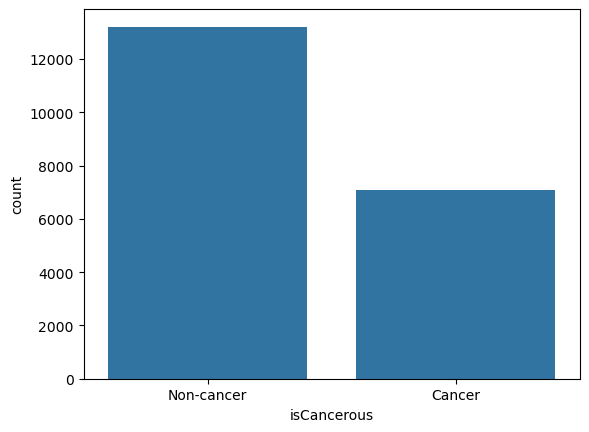

In [14]:
#bar plot
sns.countplot(data=cancer_df, x="isCancerous")
plt.xticks([0, 1], ["Non-cancer", "Cancer"])

<Axes: xlabel='cellTypeName', ylabel='count'>

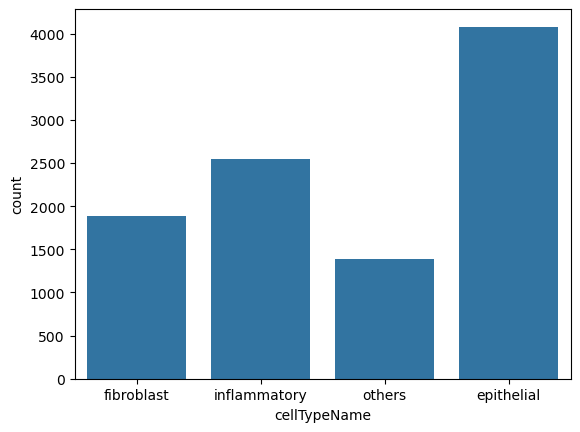

In [15]:
#bar plot 2
sns.countplot(data=cell_df, x="cellTypeName")

In [16]:
#clustering (eda)

In [17]:
def load_images(df):
    X = []
    y_cancer = []
    y_cell = []

    for _, row in df.iterrows():
        path = os.path.join(IMG_DIR, row["ImageName"])

        try:
            img = Image.open(path).convert("RGB")
            img = img.resize((32, 32))

            X.append(np.array(img).flatten())
            y_cancer.append(row["isCancerous"])
            y_cell.append(row["cellTypeName"])

        except:
            continue

    return np.array(X), np.array(y_cancer), np.array(y_cell)


X, y_cancer, y_cell = load_images(main)

print(X.shape)

(9896, 3072)


In [18]:
#use pca
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

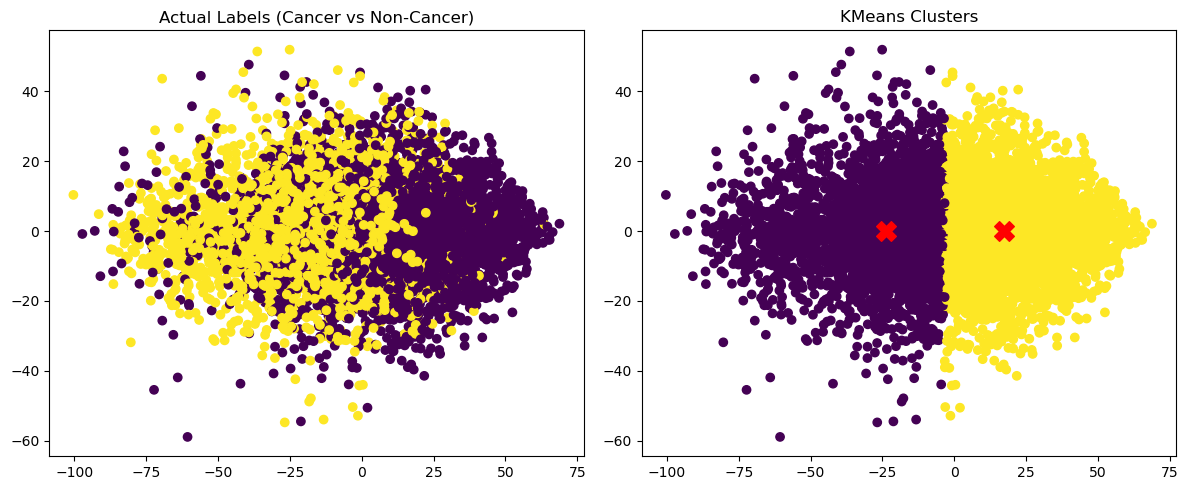

In [19]:
#k means for cacnerours or non canrours
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(X_pca)
y_kmeans = kmeans.predict(X_pca)

centers = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_cancer, cmap='viridis')
axes[0].set_title("Actual Labels (Cancer vs Non-Cancer)")

# KMeans clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
axes[1].set_title("KMeans Clusters")

plt.tight_layout()
plt.show()

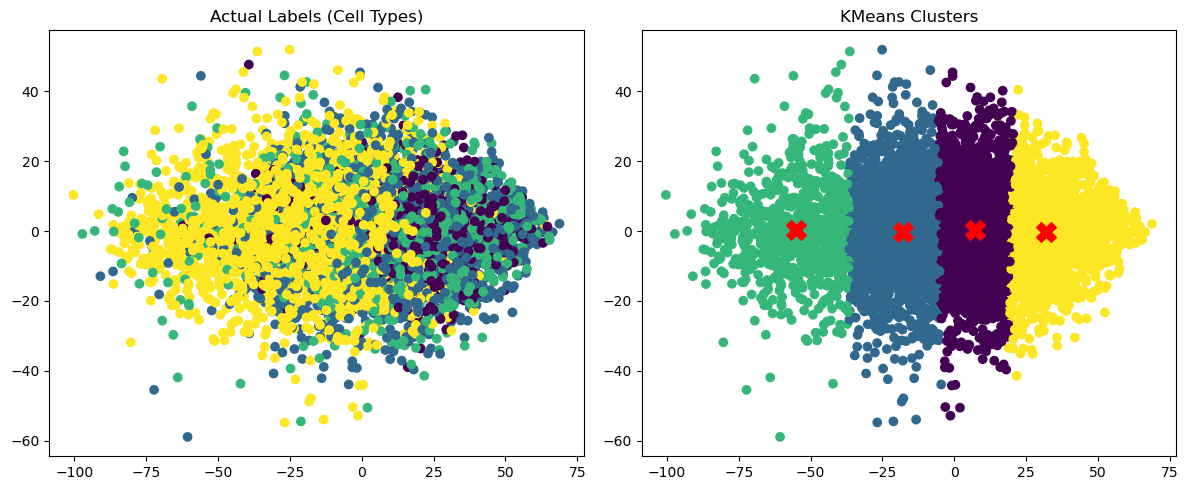

In [20]:
#k means for cell type
kmeans = KMeans(n_clusters=len(np.unique(y_cell)), random_state=0, n_init=10)
kmeans.fit(X_pca)
y_kmeans = kmeans.predict(X_pca)

centers = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(y_cell)[0], cmap='viridis')
axes[0].set_title("Actual Labels (Cell Types)")

# KMeans clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
axes[1].set_title("KMeans Clusters")

plt.tight_layout()
plt.show()

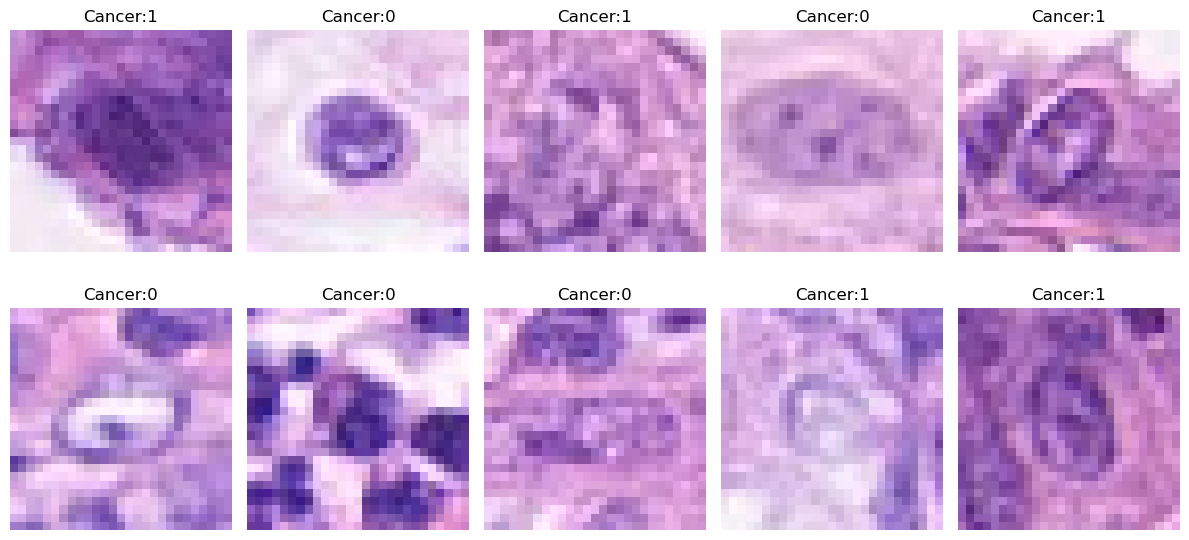

In [21]:
#view images
fig, axes = plt.subplots(2,5, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    sample = cancer_df.sample(1).iloc[0]

    img_path = os.path.join(IMG_DIR, sample["ImageName"])

    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(
        f'Cancer:{sample["isCancerous"]}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

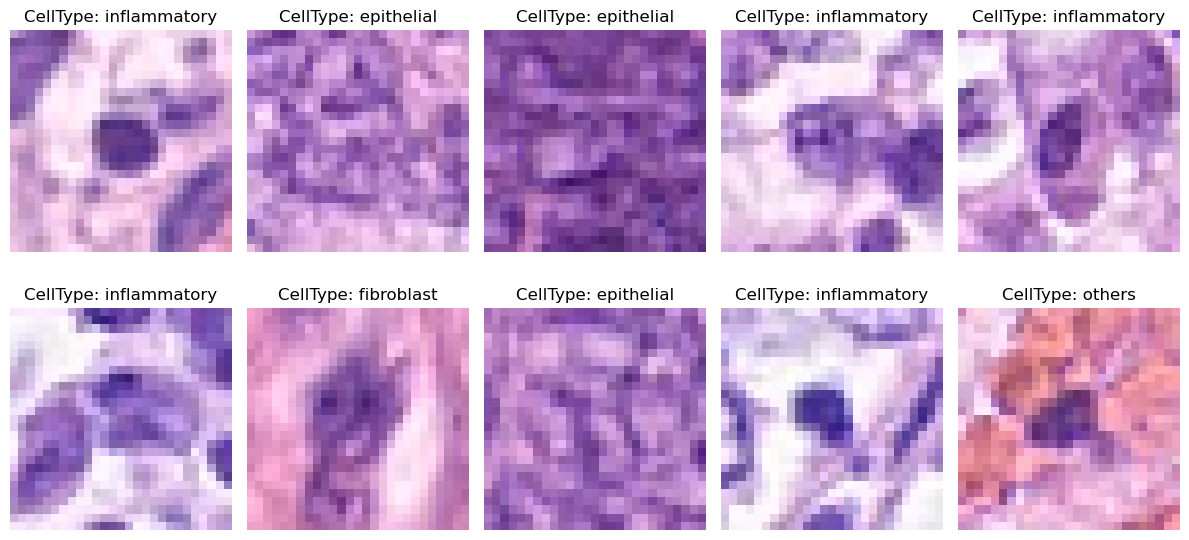

In [22]:
#same for cell type
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    sample = cell_df.sample(1).iloc[0]

    img_path = os.path.join(IMG_DIR, sample["ImageName"])

    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)

    ax.set_title(
        f'CellType: {sample["cellTypeName"]}'
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
##### data cleaning #####

In [24]:
#missing values

In [25]:
print(main.isna().sum())

InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64


In [26]:
print(extra.isna().sum())

InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64


In [27]:
#duplicates

In [28]:
cancer_df.duplicated(subset=["ImageName"]).sum()

np.int64(0)

In [29]:
cell_df.duplicated(subset=["ImageName"]).sum()

np.int64(0)

In [30]:
##### reproducbity code #####

In [31]:
#state/ seed = 42 for everything

import random
SEED = 42

#python random
random.seed(SEED)

#numPy random
np.random.seed(SEED)

#pyTorch random
torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [32]:
g = torch.Generator()
g.manual_seed(SEED)

In [33]:
##### encode #####

In [34]:
# cancer 0,1
# cell 0,1,2,3
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cancer_df["cellType_encoded"] = le.fit_transform(cancer_df["cellTypeName"])
cell_df["cellType_encoded"] = le.fit_transform(cell_df["cellTypeName"])

In [35]:
##### splitting #####

In [36]:
#hold out validation

#cancer task(use cancer df)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(cancer_df, groups=cancer_df["patientID"]))

train_df = cancer_df.iloc[train_idx].copy()
test_df = cancer_df.iloc[test_idx].copy()

# validation split 
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx2, val_idx = next(
    gss_val.split(train_df, groups=train_df["patientID"])
)

train_df_final = train_df.iloc[train_idx2].copy()
val_df = train_df.iloc[val_idx].copy()

In [37]:
#cell task (uses cell df)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(cell_df, groups=cell_df["patientID"]))

train_cell_df = cell_df.iloc[train_idx].copy()
test_cell_df = cell_df.iloc[test_idx].copy()

# validation split 
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx2, val_idx = next(
    gss_val.split(train_cell_df, groups=train_cell_df["patientID"])
)

train_cell_df_final = train_cell_df.iloc[train_idx2].copy()
val_cell_df = train_cell_df.iloc[val_idx].copy()

In [ ]:
#check splits

In [38]:
#cancer
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 16324
Val: 3908
Test: 3956


In [39]:
#cell
print("Train:", len(train_cell_df))
print("Val:", len(val_cell_df))
print("Test:", len(test_cell_df))

Train: 8057
Val: 2386
Test: 1839


In [40]:
##### model 1 cnn neural network (with advanced techqnue "transfer learning") #####

In [41]:
#loading histology image data
#function for both tasks
from torch.utils.data import Dataset
from PIL import Image
import os
import numpy as np

class HistologyDataset(Dataset):
    def __init__(self, df, img_dir="./data/images", task="cancer", transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.task = task
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["ImageName"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.task == "cancer":
            label = row["isCancerous"]
        else:
            label = row["cellType_encoded"]

        return image, label

In [42]:
#resize from orginal 27 to 32

import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [43]:
#use cpu precoessing power
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [44]:
#base model simple cnn 
#for both tasks
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [45]:
#advanced model VGG model (with dropout hyperparemter test)
class VGGNet(nn.Module):
    #def __init__(self, num_classes, dropout=0.2):#good
    #def __init__(self, num_classes, dropout=0.3):#second best
    def __init__(self, num_classes, dropout=0.4):#best
    #def __init__(self, num_classes, dropout=0.5):#not so good
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [46]:
#data pipeline for the cancer task
#(batch sioze 32 for all)

from torch.utils.data import DataLoader

# cancer datasets
train_cancer = HistologyDataset(
    train_df_final,
    img_dir=IMG_DIR,
    task="cancer",
    transform=train_transform
)

val_cancer = HistologyDataset(
    val_df,
    img_dir=IMG_DIR,
    task="cancer",
    transform=val_transform
)

test_cancer = HistologyDataset(
    test_df,
    img_dir=IMG_DIR,
    task="cancer",
    transform=val_transform
)

# cancer loaders
train_loader_cancer = DataLoader(
    train_cancer,
    batch_size=32,
    shuffle=True,
    generator=g
)

val_loader_cancer = DataLoader(
    val_cancer,
    batch_size=32,
    shuffle=False,
    generator=g
)

test_loader_cancer = DataLoader(
    test_cancer,
    batch_size=32,
    shuffle=False,
    generator=g
)

In [47]:
#data pipeline for the celltype task (same as above)

# cell datasets
train_cell = HistologyDataset(
    train_cell_df_final,
    img_dir=IMG_DIR,
    task="cell",
    transform=train_transform
)

val_cell = HistologyDataset(
    val_cell_df,
    img_dir=IMG_DIR,
    task="cell",
    transform=val_transform
)

test_cell = HistologyDataset(
    test_cell_df,
    img_dir=IMG_DIR,
    task="cell",
    transform=val_transform
)

# our cell loaders
train_loader_cell = DataLoader(
    train_cell,
    batch_size=32,
    shuffle=True,
    generator=g
)

val_loader_cell = DataLoader(
    val_cell,
    batch_size=32,
    shuffle=False,
    generator=g
)

test_loader_cell = DataLoader(
    test_cell,
    batch_size=32,
    shuffle=False,
    generator=g
)

In [48]:
#prepares the datasets

#cancer
train_cancer = HistologyDataset(
    train_df,
    task="cancer",
    transform=train_transform
)

val_cancer = HistologyDataset(
    val_df,
    task="cancer",
    transform=val_transform
)

test_cancer = HistologyDataset(
    test_df,
    task="cancer",
    transform=val_transform
)

#cell
train_cell = HistologyDataset(
    train_cell_df,
    task="cell",
    transform=train_transform
)

val_cell = HistologyDataset(
    val_cell_df,
    task="cell",
    transform=val_transform
)

test_cell = HistologyDataset(
    test_cell_df,
    task="cell",
    transform=val_transform
)

In [49]:
#plot function (loss and accuracy over epochs)(same as our wek 9 code)

import matplotlib.pyplot as plt
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()
    
    plt.show()

In [50]:
#train function
# for base model 

def train_model(model, train_loader, val_loader,
                lr=1e-3, epochs=10, weight_decay=1e-4, class_weights=None):

    model = model.to(device)
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

#train
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

#validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                loss = criterion(out, y)

                val_loss += loss.item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} — "
              f"train_loss: {train_loss:.4f}, "
              f"val_loss: {val_loss:.4f}, "
              f"train_acc: {train_acc:.4f}, "
              f"val_acc: {val_acc:.4f}")

    return model, history

In [51]:
#adding class weights
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#cancer
cancer_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df_final["isCancerous"]
)

cancer_weights = torch.tensor(cancer_weights, dtype=torch.float)

#cell
cell_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_cell_df_final["cellType_encoded"]),
    y=train_cell_df_final["cellType_encoded"]
)

cell_weights = torch.tensor(cell_weights, dtype=torch.float)

In [52]:
#evaldation function
# gives us macro f1 and accuracy

def evaluate(model, loader):
    model.eval()

    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    print("F1 macro:", f1_score(labels_all, preds_all, average="macro"))
    print("Accuracy:", accuracy_score(labels_all, preds_all))

In [53]:
le = LabelEncoder()
main["cellType_encoded"] = le.fit_transform(main["cellTypeName"])

In [54]:
#2 classifcation outputs
cancer_model = SimpleCNN(num_classes=2)

In [55]:
#4 classifcation outputs
cell_model = SimpleCNN(num_classes=len(main["cellType_encoded"].unique()))

Epoch 1/10 — train_loss: 0.5280, val_loss: 0.4564, train_acc: 0.7645, val_acc: 0.7789
Epoch 2/10 — train_loss: 0.3607, val_loss: 0.3888, train_acc: 0.8508, val_acc: 0.8153
Epoch 3/10 — train_loss: 0.3384, val_loss: 0.3705, train_acc: 0.8581, val_acc: 0.8329
Epoch 4/10 — train_loss: 0.3266, val_loss: 0.3788, train_acc: 0.8636, val_acc: 0.8263
Epoch 5/10 — train_loss: 0.3191, val_loss: 0.3557, train_acc: 0.8677, val_acc: 0.8408
Epoch 6/10 — train_loss: 0.3158, val_loss: 0.3552, train_acc: 0.8668, val_acc: 0.8398
Epoch 7/10 — train_loss: 0.3119, val_loss: 0.3477, train_acc: 0.8686, val_acc: 0.8457
Epoch 8/10 — train_loss: 0.3133, val_loss: 0.4132, train_acc: 0.8708, val_acc: 0.8068
Epoch 9/10 — train_loss: 0.3100, val_loss: 0.4166, train_acc: 0.8714, val_acc: 0.8063
Epoch 10/10 — train_loss: 0.3053, val_loss: 0.3472, train_acc: 0.8738, val_acc: 0.8442
F1 macro: 0.8376831022643269
Accuracy: 0.8441658137154555


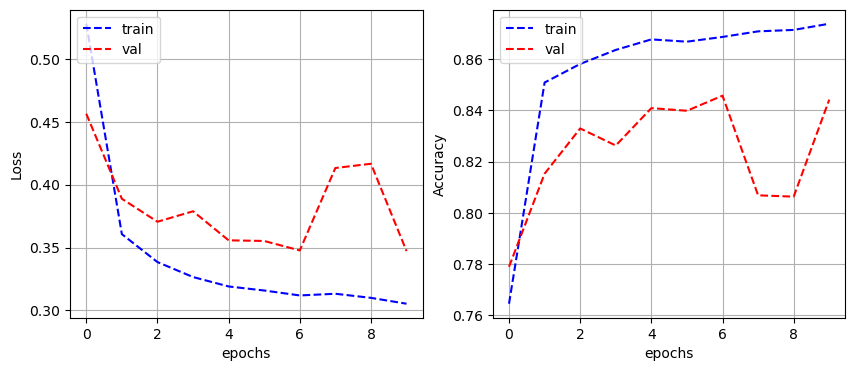

In [56]:
# run cancer base model
cancer_model, history_cancer = train_model(
    cancer_model,
    train_loader_cancer,
    val_loader_cancer,
    lr=1e-4,
    class_weights=cancer_weights#
)

evaluate(cancer_model, val_loader_cancer)

plot_learning_curve(
    history_cancer["train_loss"],
    history_cancer["val_loss"],
    history_cancer["train_acc"],
    history_cancer["val_acc"],
    metric_name="Accuracy"
)

Epoch 1/10 — train_loss: 1.1689, val_loss: 0.9954, train_acc: 0.5228, val_acc: 0.5704
Epoch 2/10 — train_loss: 0.8821, val_loss: 0.8987, train_acc: 0.6817, val_acc: 0.6027
Epoch 3/10 — train_loss: 0.8258, val_loss: 0.8946, train_acc: 0.6985, val_acc: 0.6249
Epoch 4/10 — train_loss: 0.8250, val_loss: 0.7999, train_acc: 0.7004, val_acc: 0.6622
Epoch 5/10 — train_loss: 0.7830, val_loss: 0.9167, train_acc: 0.7270, val_acc: 0.5872
Epoch 6/10 — train_loss: 0.7872, val_loss: 0.7895, train_acc: 0.7196, val_acc: 0.6718
Epoch 7/10 — train_loss: 0.7660, val_loss: 0.8134, train_acc: 0.7249, val_acc: 0.6731
Epoch 8/10 — train_loss: 0.7314, val_loss: 0.7657, train_acc: 0.7399, val_acc: 0.6894
Epoch 9/10 — train_loss: 0.7403, val_loss: 0.8212, train_acc: 0.7311, val_acc: 0.6676
Epoch 10/10 — train_loss: 0.7121, val_loss: 0.8139, train_acc: 0.7482, val_acc: 0.6580
F1 macro: 0.5901956282723944
Accuracy: 0.6580050293378038


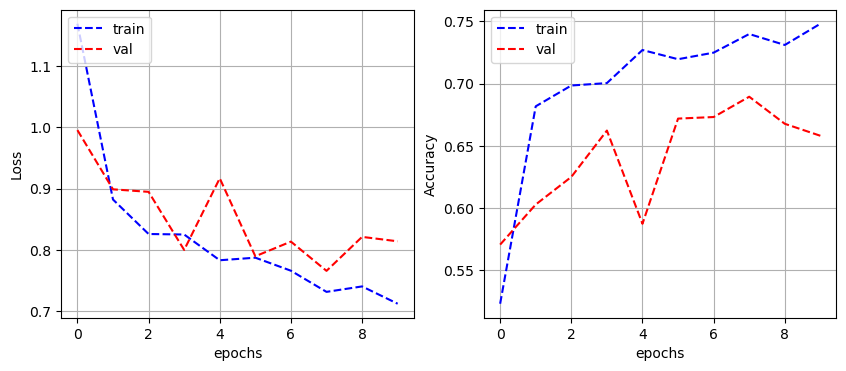

In [57]:
# runs cell base model
cell_model, history_cell = train_model(
    cell_model,
    train_loader_cell,
    val_loader_cell,
    lr=1e-3,
    class_weights=cell_weights#
)

evaluate(cell_model, val_loader_cell)

plot_learning_curve(
    history_cell["train_loss"],
    history_cell["val_loss"],
    history_cell["train_acc"],
    history_cell["val_acc"],
    metric_name="Accuracy"
)

In [58]:
#adavcned techqnue transfer learning

In [59]:
#transpfrmations then data import for cifar10

#provided code(size, shape and colour adjustements)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),   
    transforms.RandomRotation(20),     
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),                                
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914,0.4822,0.4465),
        std=(0.2470,0.2435,0.2616)
    )
])

cifar_train = torchvision.datasets.CIFAR10(
    root="./cifar",
    train=True,
    download=True,
    transform=transform
)

cifar_loader = DataLoader(
    cifar_train,
    batch_size=64,
    shuffle=True,
    generator=g
)

In [60]:
#train cifar using vgg model (test hyperparemters optimzers)

cifar_model = VGGNet(num_classes=10).to(device)

#optimizer = optim.Adam(cifar_model.parameters(), lr=1e-4)#worst
#optimizer = optim.Adam(cifar_model.parameters(), lr=1e-3)#good
#optimizer = optim.AdamW(cifar_model.parameters(), lr=1e-3, weight_decay=1e-4)#second best
optimizer = torch.optim.Adam(cifar_model.parameters(), lr=1e-3, weight_decay=0.0)#f1 0.879 0.5676 best

loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    for x, y in cifar_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = loss_fn(cifar_model(x), y)
        loss.backward()
        optimizer.step()

    print("CIFAR epoch done")

CIFAR epoch done
CIFAR epoch done
CIFAR epoch done
CIFAR epoch done
CIFAR epoch done


Epoch 1/60 — train_loss: 0.5340, val_loss: 0.4761, train_acc: 0.7208, val_acc: 0.7602
Epoch 2/60 — train_loss: 0.3783, val_loss: 0.4309, train_acc: 0.8336, val_acc: 0.7948
Epoch 3/60 — train_loss: 0.3377, val_loss: 0.3993, train_acc: 0.8551, val_acc: 0.8132
Epoch 4/60 — train_loss: 0.3154, val_loss: 0.3556, train_acc: 0.8694, val_acc: 0.8367
Epoch 5/60 — train_loss: 0.3004, val_loss: 0.3269, train_acc: 0.8772, val_acc: 0.8549
Epoch 6/60 — train_loss: 0.2945, val_loss: 0.3189, train_acc: 0.8784, val_acc: 0.8631
Epoch 7/60 — train_loss: 0.2824, val_loss: 0.3172, train_acc: 0.8849, val_acc: 0.8603
Epoch 8/60 — train_loss: 0.2807, val_loss: 0.3091, train_acc: 0.8843, val_acc: 0.8641
Epoch 9/60 — train_loss: 0.2744, val_loss: 0.3025, train_acc: 0.8890, val_acc: 0.8705
Epoch 10/60 — train_loss: 0.2674, val_loss: 0.3015, train_acc: 0.8910, val_acc: 0.8682
Epoch 11/60 — train_loss: 0.2640, val_loss: 0.2992, train_acc: 0.8930, val_acc: 0.8690
Epoch 12/60 — train_loss: 0.2614, val_loss: 0.2955, 

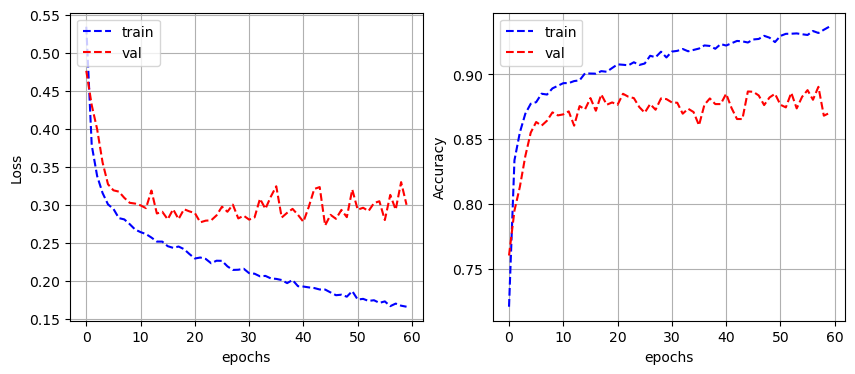

Epoch 1/50 — train_loss: 0.9913, val_loss: 0.9233, train_acc: 0.5941, val_acc: 0.6379
Epoch 2/50 — train_loss: 0.7465, val_loss: 0.8388, train_acc: 0.7161, val_acc: 0.6832
Epoch 3/50 — train_loss: 0.6792, val_loss: 0.7674, train_acc: 0.7445, val_acc: 0.6974
Epoch 4/50 — train_loss: 0.6558, val_loss: 0.8759, train_acc: 0.7496, val_acc: 0.6714
Epoch 5/50 — train_loss: 0.6264, val_loss: 0.7608, train_acc: 0.7612, val_acc: 0.7066
Epoch 6/50 — train_loss: 0.6111, val_loss: 0.8543, train_acc: 0.7752, val_acc: 0.7012
Epoch 7/50 — train_loss: 0.5919, val_loss: 0.8354, train_acc: 0.7773, val_acc: 0.6999
Epoch 8/50 — train_loss: 0.5652, val_loss: 0.8414, train_acc: 0.7866, val_acc: 0.7003
Epoch 9/50 — train_loss: 0.5717, val_loss: 1.0179, train_acc: 0.7900, val_acc: 0.6622
Epoch 10/50 — train_loss: 0.5556, val_loss: 0.8480, train_acc: 0.7865, val_acc: 0.7091
Epoch 11/50 — train_loss: 0.5282, val_loss: 0.7032, train_acc: 0.8014, val_acc: 0.7276
Epoch 12/50 — train_loss: 0.5246, val_loss: 0.7499, 

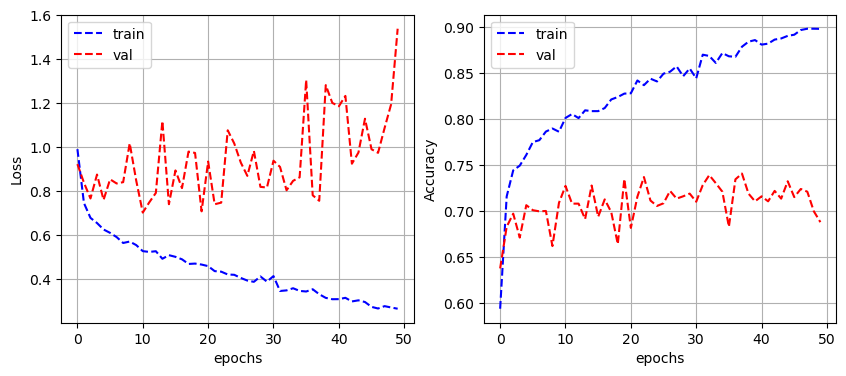

In [61]:
#run cell and cacner tasks
#we test epochs and learnign rate

import copy

cancer_transfer = copy.deepcopy(cifar_model)
cell_transfer = copy.deepcopy(cifar_model)

num_classes = len(train_cell_df["cellType_encoded"].unique())

cancer_transfer.classifier[-1] = nn.Linear(128, 2)
cell_transfer.classifier[-1] = nn.Linear(128, num_classes)

cancer_transfer = cancer_transfer.to(device)
cell_transfer = cell_transfer.to(device)

cancer_transfer, history_cancer_transfer = train_model(
    cancer_transfer,
    train_loader_cancer,
    val_loader_cancer,
    #lr=1e-3, #lr=1e-3, 20 epoch, val mcaro f1 0.8186834844304296, val accuracy 0.8420121334681496
    lr=1e-4,#lr=1e-4, 30 epoch, val mcaro f1 0.841950851801598, val accuracy 0.8660262891809909 best
    #epochs=20
    #epochs=30
    #epochs=50 #second best
    epochs=60 #best 
    #higher epochs reduced score
)

evaluate(cancer_transfer, val_loader_cancer)

plot_learning_curve(
    history_cancer_transfer["train_loss"],
    history_cancer_transfer["val_loss"],
    history_cancer_transfer["train_acc"],
    history_cancer_transfer["val_acc"],
    metric_name="Accuracy"
)

cell_transfer, history_cell_transfer = train_model(
    cell_transfer,
    train_loader_cell,
    val_loader_cell,
    lr=1e-3, #best
    #lr=1e-4, #second best
    #epochs=20 
    #epochs=30
    epochs=50     #best
)


evaluate(cell_transfer, val_loader_cell)

plot_learning_curve(
    history_cell_transfer["train_loss"],
    history_cell_transfer["val_loss"],
    history_cell_transfer["train_acc"],
    history_cell_transfer["val_acc"],
    metric_name="Accuracy"
)

In [96]:
#test function
# accuracy, macroF1 and clasfication report

from sklearn.metrics import accuracy_score, f1_score, classification_report

def test_model(model, loader, name="Test Set"):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [97]:
test_model(cancer_transfer, test_loader_cancer, name="Cancer Test Set") #f1 0.87 results close to accuracy


Cancer Test Set
Accuracy: 0.8951
Macro F1: 0.8706

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2909
           1       0.77      0.87      0.81      1047

    accuracy                           0.90      3956
   macro avg       0.86      0.89      0.87      3956
weighted avg       0.90      0.90      0.90      3956



In [98]:
test_model(cell_transfer, test_loader_cell, name="Cell Test Set") #f1 0.609 met thresho9ld accuracy is higher than f1


Cell Test Set
Accuracy: 0.6857
Macro F1: 0.6094

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83       925
           1       0.52      0.62      0.56       261
           2       0.61      0.70      0.65       432
           3       0.35      0.44      0.39       221

    accuracy                           0.69      1839
   macro avg       0.60      0.63      0.61      1839
weighted avg       0.73      0.69      0.70      1839



In [65]:
##### model 2 (random forest(decision tree)) ######

In [66]:
import os
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [67]:
le = LabelEncoder()
main["cellType_encoded"] = le.fit_transform(main["cellTypeName"])

In [68]:
IMG_DIR = "./data/images"
IMG_SIZE = (32, 32)

def prepare_images(df):
    X = []
    y_cancer = []
    y_cell = []

    for _, row in df.iterrows():
        path = os.path.join(IMG_DIR, row["ImageName"])

        try:
            img = Image.open(path).convert("RGB")
            img = img.resize(IMG_SIZE)

            img_array = np.array(img).flatten()

            X.append(img_array)
            y_cancer.append(row["isCancerous"])
            y_cell.append(row["cellType_encoded"])

        except:
            continue

    return np.array(X), np.array(y_cancer), np.array(y_cell)

In [69]:
#cancer
X_train, y_train_cancer, _ = prepare_images(train_df)
X_val, y_val_cancer, _ = prepare_images(val_df)
X_test, y_test_cancer, _ = prepare_images(test_df)

In [70]:
#cell
X_train_cell, _, y_train_cell = prepare_images(train_cell_df)
X_val_cell, _, y_val_cell = prepare_images(val_cell_df)
X_test_cell, _, y_test_cell = prepare_images(test_cell_df)

In [71]:
#cancer sclaing/ pca
scaler_cancer = StandardScaler()

X_train_scaled = scaler_cancer.fit_transform(X_train)
X_val_scaled = scaler_cancer.transform(X_val)
X_test_scaled = scaler_cancer.transform(X_test)

pca_cancer = PCA(n_components=250)

X_train_pca = pca_cancer.fit_transform(X_train_scaled)
X_val_pca = pca_cancer.transform(X_val_scaled)
X_test_pca = pca_cancer.transform(X_test_scaled)

In [72]:
#cell slcaing/ pca
scaler_cell = StandardScaler()

X_train_cell_scaled = scaler_cell.fit_transform(X_train_cell)
X_val_cell_scaled = scaler_cell.transform(X_val_cell)
X_test_cell_scaled = scaler_cell.transform(X_test_cell)

pca_cell = PCA(n_components=250)

X_train_cell_pca = pca_cell.fit_transform(X_train_cell_scaled)
X_val_cell_pca = pca_cell.transform(X_val_cell_scaled)
X_test_cell_pca = pca_cell.transform(X_test_cell_scaled)

In [73]:
#cancer rf model
rf_cancer = RandomForestClassifier(
    #max_depth=8,
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_features='sqrt'
)

rf_cancer.fit(X_train_pca, y_train_cancer)

y_pred_cancer = rf_cancer.predict(X_test_pca)

print("cancer task")
print("Accuracy:", accuracy_score(y_test_cancer, y_pred_cancer))
print("Macro F1:", f1_score(y_test_cancer, y_pred_cancer, average='macro'))
print(classification_report(y_test_cancer, y_pred_cancer))
print(confusion_matrix(y_test_cancer, y_pred_cancer))

cancer task
Accuracy: 0.872093023255814
Macro F1: 0.8315935204927742
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      2909
           1       0.78      0.72      0.75      1047

    accuracy                           0.87      3956
   macro avg       0.84      0.82      0.83      3956
weighted avg       0.87      0.87      0.87      3956

[[2695  214]
 [ 292  755]]


In [74]:
#cell rf model
rf_cell = RandomForestClassifier(
    #max_depth=8,
    n_estimators=400,
    min_samples_split=3,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    max_features='sqrt'
)

rf_cell.fit(X_train_cell_pca, y_train_cell)

y_pred_cell = rf_cell.predict(X_test_cell_pca)

print("cell task")
print("Accuracy:", accuracy_score(y_test_cell, y_pred_cell))
print("Macro F1:", f1_score(y_test_cell, y_pred_cell, average='macro'))
print(classification_report(y_test_cell, y_pred_cell))
print(confusion_matrix(y_test_cell, y_pred_cell))

cell task
Accuracy: 0.6460032626427407
Macro F1: 0.4430053126164465
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       925
           1       0.71      0.25      0.37       261
           2       0.48      0.83      0.61       432
           3       0.00      0.00      0.00       221

    accuracy                           0.65      1839
   macro avg       0.49      0.48      0.44      1839
weighted avg       0.60      0.65      0.60      1839

[[763   3 159   0]
 [110  65  85   1]
 [ 58  14 360   0]
 [ 62   9 150   0]]


In [75]:
##### model 3 (SVM) #####

In [76]:
from sklearn.svm import SVC

In [77]:
#cancer
svm_cancer = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=SEED
)

svm_cancer.fit(X_train_pca, y_train_cancer)

y_pred_cancer = svm_cancer.predict(X_test_pca)

print("Cancer Task")
print("Accuracy:", accuracy_score(y_test_cancer, y_pred_cancer))
print("Macro F1:", f1_score(y_test_cancer, y_pred_cancer, average='macro'))
print(classification_report(y_test_cancer, y_pred_cancer))
print(confusion_matrix(y_test_cancer, y_pred_cancer))

Cancer Task
Accuracy: 0.8677957532861477
Macro F1: 0.8422099821335516
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      2909
           1       0.70      0.88      0.78      1047

    accuracy                           0.87      3956
   macro avg       0.83      0.87      0.84      3956
weighted avg       0.88      0.87      0.87      3956

[[2513  396]
 [ 127  920]]


In [87]:
#cell
svm_cell = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=SEED
)

svm_cell.fit(X_train_cell_pca, y_train_cell)

y_pred_cell = svm_cell.predict(X_test_cell_pca)

print("Cell Task")
print("Accuracy:", accuracy_score(y_test_cell, y_pred_cell))
print("Macro F1:", f1_score(y_test_cell, y_pred_cell, average='macro'))
print(classification_report(y_test_cell, y_pred_cell))
print(confusion_matrix(y_test_cell, y_pred_cell))

Cell Task
Accuracy: 0.6965742251223491
Macro F1: 0.5820315840921085
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       925
           1       0.58      0.46      0.51       261
           2       0.55      0.80      0.66       432
           3       0.39      0.26      0.31       221

    accuracy                           0.70      1839
   macro avg       0.60      0.58      0.58      1839
weighted avg       0.70      0.70      0.69      1839

[[758  28 114  25]
 [ 60 119  54  28]
 [ 20  29 346  37]
 [ 23  30 110  58]]
